**Alishba Bacha**

**AI - 351**

**Assignment 2**

Important libraries

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

Load data set and check for its columns

In [33]:
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**A: Data Exploration**

In [123]:
# Check the unique classes in 'num' column
unique_classes, class_counts = np.unique(df['num'], return_counts=True)

print(f"Unique classes in 'num': {unique_classes}")

Unique classes in 'num': [0. 1. 2. 3. 4.]


  Check missing Values

In [124]:
df.isnull().sum()

,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


  Statistical Analysis

In [78]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,9.424685,18.443895,108.957634,25.138494,1.053774,0.541667,1.142693
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.676375,0.000000
50%,54.000000,130.000000,221.000000,138.000000,0.800000,0.676375,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.676375,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


   Relation between neumerical features

<Figure size 800x600 with 0 Axes>

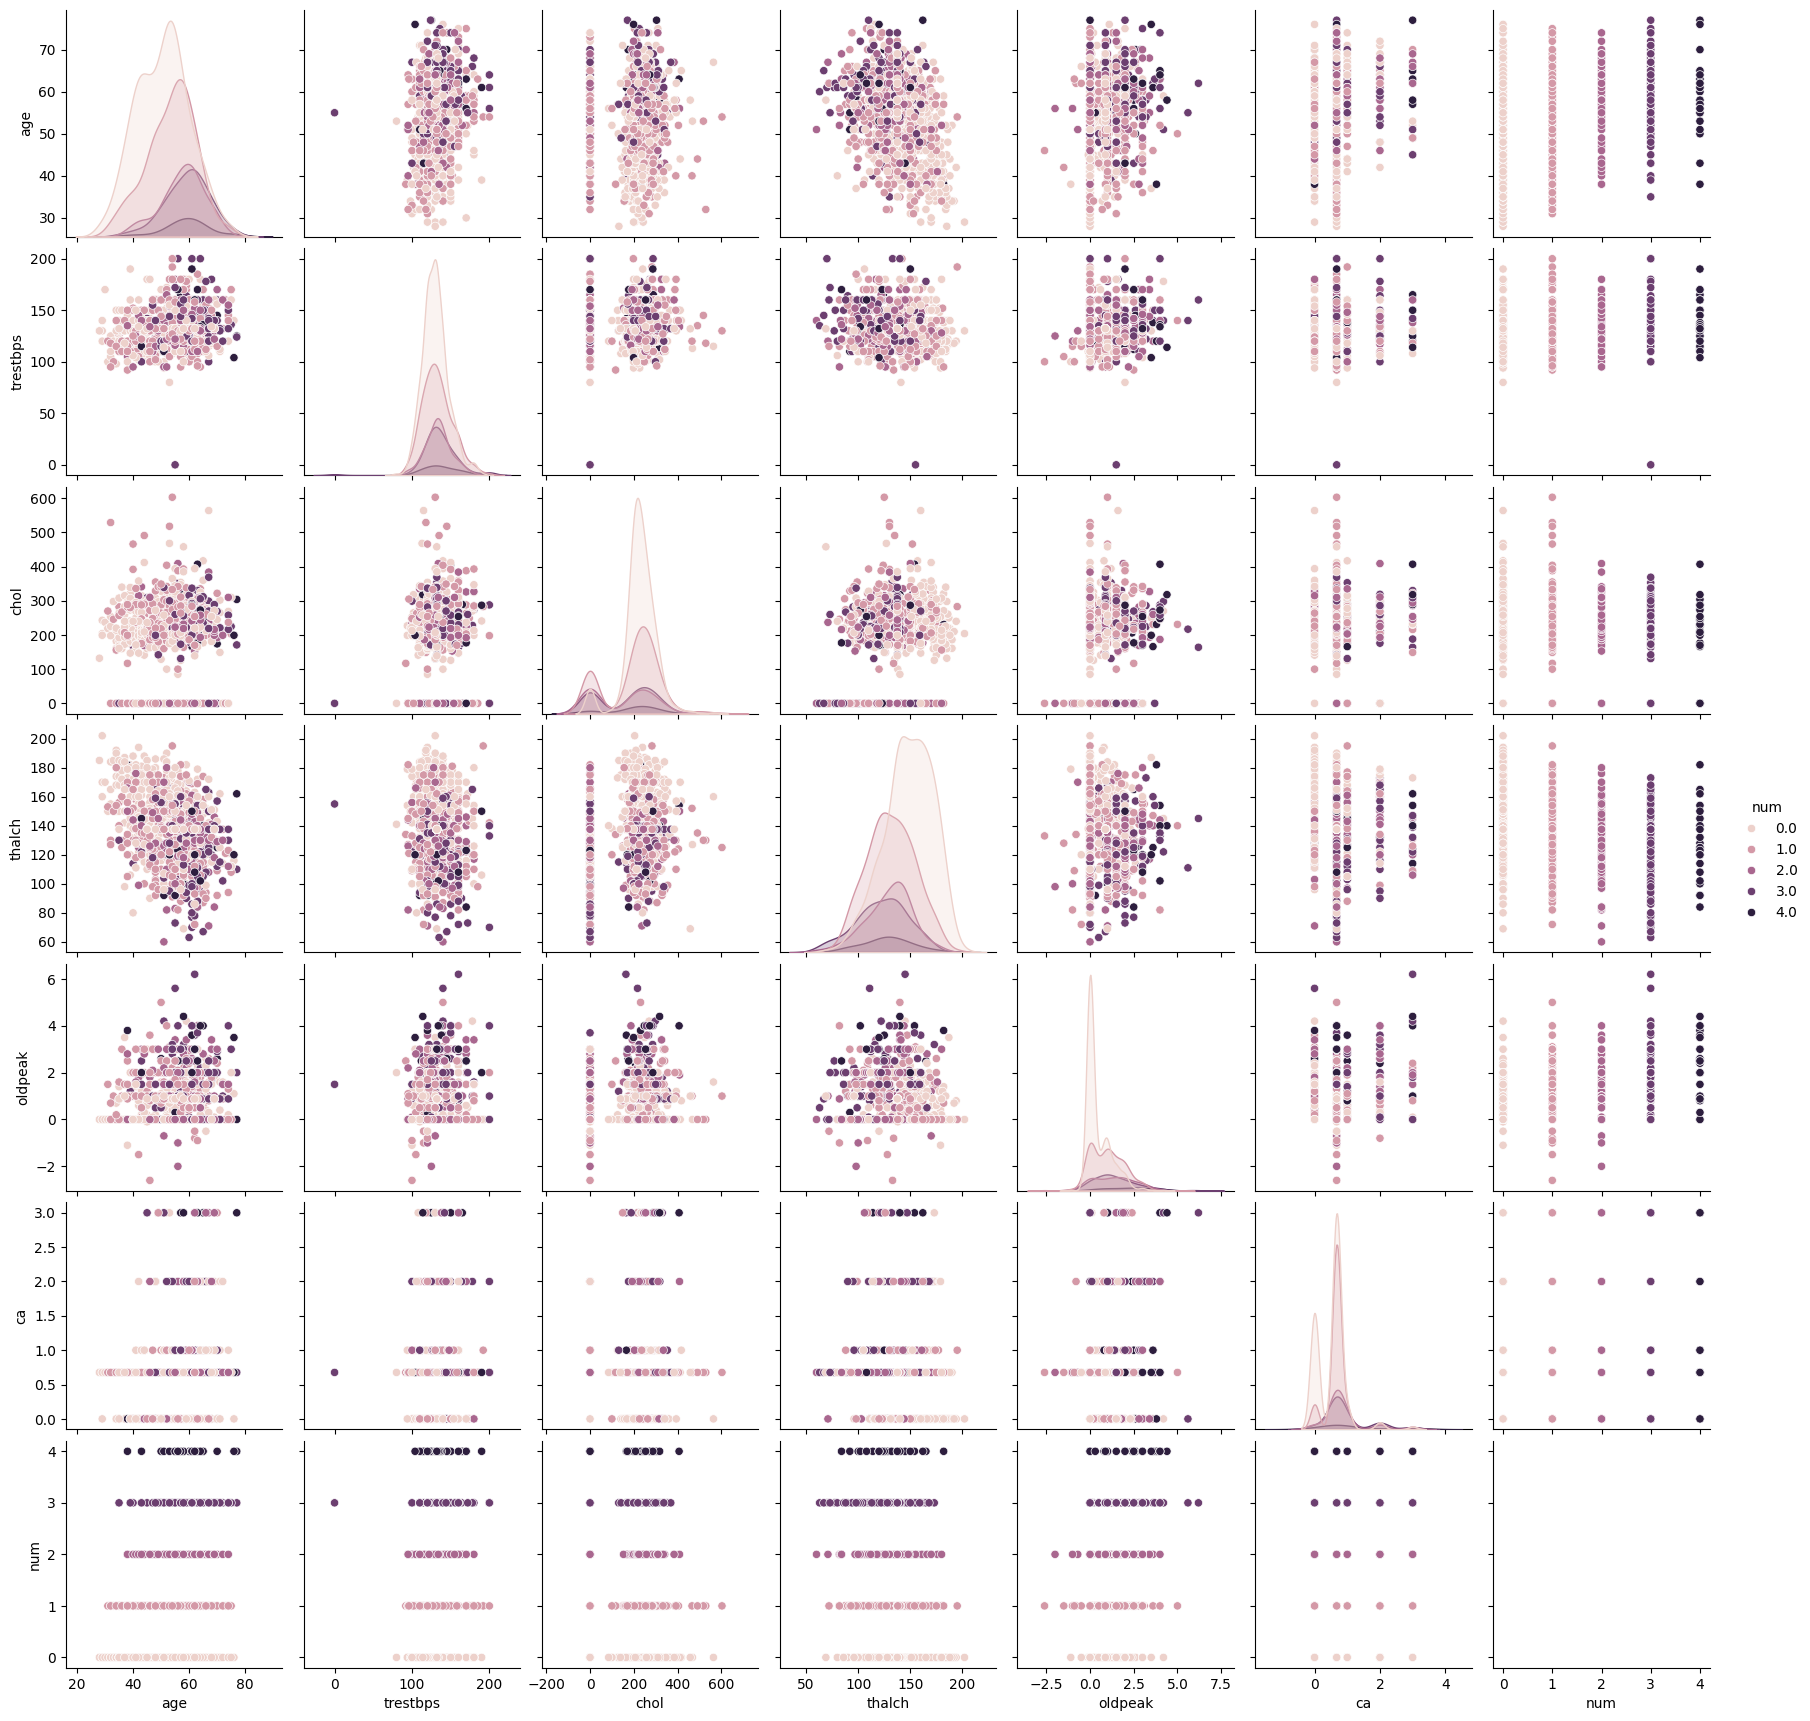

In [79]:
numerical_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8,6))
sns.pairplot(df,vars=numerical_features,hue="num")
plt.show()

   Visuals of neumeric columns

<Figure size 1000x600 with 0 Axes>

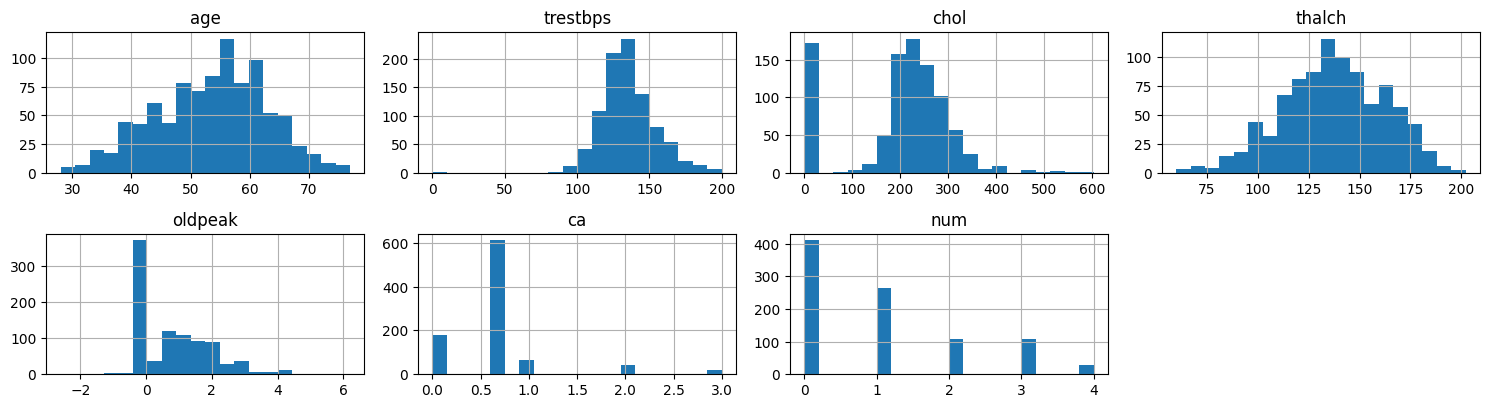

In [80]:
plt.figure(figsize=(10, 6))
df.hist(bins=20, figsize=(15, 10), layout=(5, 4))
plt.tight_layout()
plt.show()

  Correlation heatmap for neumerical features

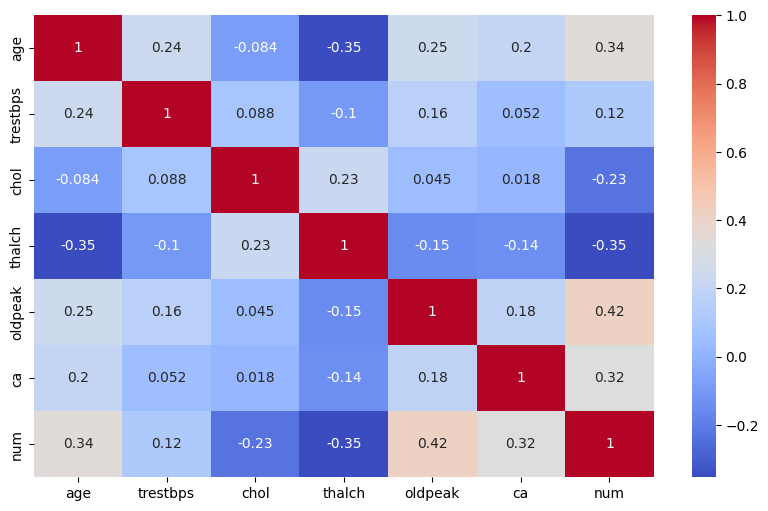

In [84]:
# Select only numeric features for correlation
numeric_df = df.select_dtypes(include=['number'])

# Correlation heatmap for numeric features
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

  Distribution of numeric value age

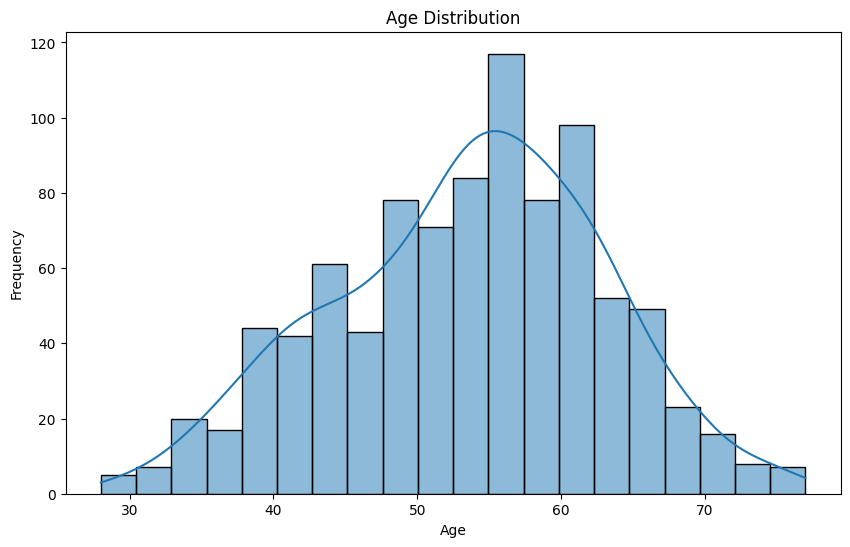

In [86]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

   Distribution of Catagorical value cholestrol

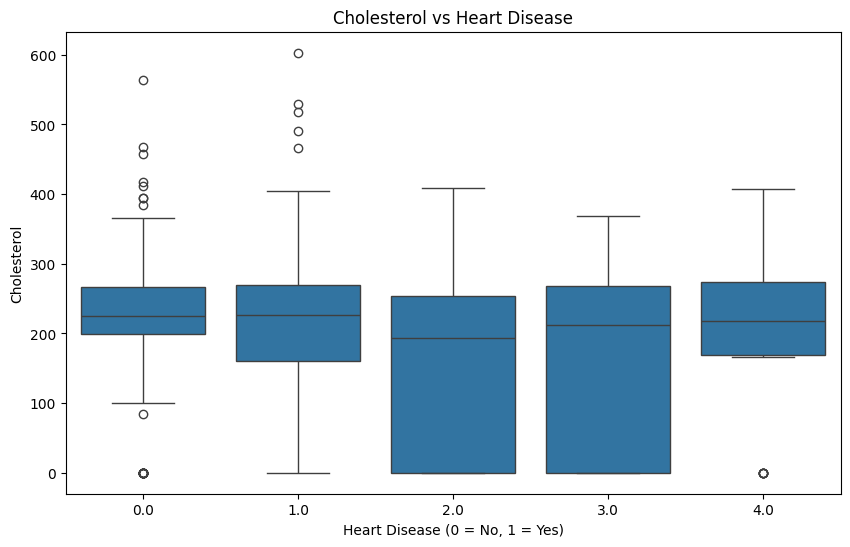

In [88]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='num', y='chol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Cholesterol')
plt.show()

  Relation between catagorical and target variable

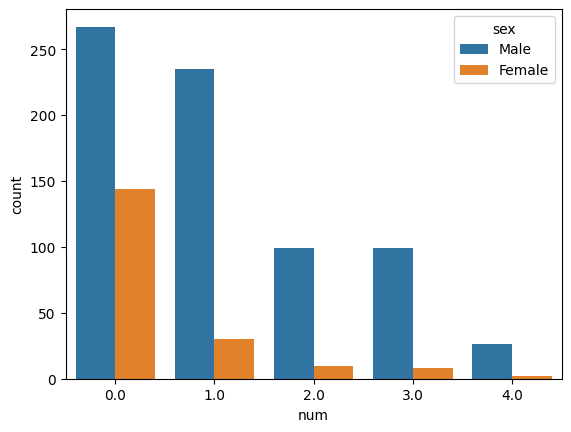

In [89]:
sns.countplot(data=df, x='num', hue='sex')
plt.show()

**2: Data Preprocessing**

 Handling missing value

In [91]:
df.dropna(inplace=True)

  Encoding catagorical value

In [93]:
data = pd.get_dummies(df, columns=['cp', 'restecg', 'thal', 'slope'], drop_first=True)

  Identify catgoric and numeric values and scale them

In [97]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'ca']
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # Scale numeric features
        ('cat', OneHotEncoder(), categorical_cols)  # One-hot encode categorical features
    ])


  Train test spliting

In [98]:
X = data.drop(['num'], axis=1)
y = data['num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

**3: Model Evaluation**

  1: AdaBoost

   **.Classifier**

In [105]:
from sklearn.metrics import classification_report

# Initialize and fit AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
ada_model.fit(X_train_processed, y_train)

# Predictions
y_pred = ada_model.predict(X_test_processed)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f'AdaBoost Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Accuracy: 0.50
              precision    recall  f1-score   support

         0.0       0.65      0.81      0.72        75
         1.0       0.38      0.44      0.41        54
         2.0       0.33      0.24      0.28        25
         3.0       0.14      0.04      0.06        26
         4.0       0.00      0.00      0.00         4

    accuracy                           0.50       184
   macro avg       0.30      0.31      0.29       184
weighted avg       0.44      0.50      0.46       184



  **.Evaluation**

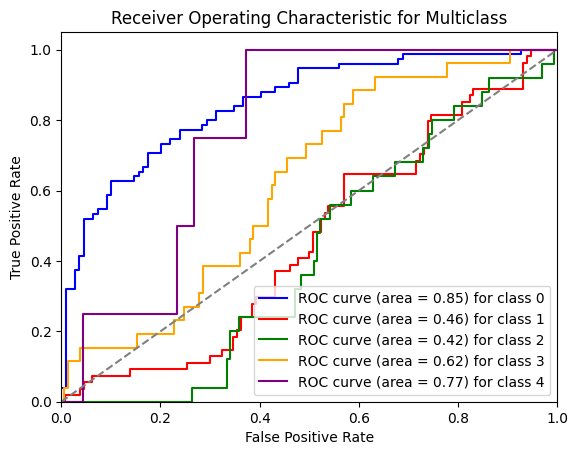

In [107]:
# Binarize the output
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = y_test_binarized.shape[1]

# Get prediction probabilities for all classes
y_prob = ada_model.predict_proba(X_test_processed)

# Compute ROC AUC for each class
roc_auc = dict()
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr, tpr)

# Plotting ROC Curve for each class
plt.figure()
colors = ['blue', 'red', 'green', 'orange', 'purple']  # Add more colors if necessary
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, color=color, label=f'ROC curve (area = {roc_auc[i]:.2f}) for class {i}')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multiclass')
plt.legend(loc='lower right')
plt.show()


2: Gradient Boosting

 **.Classifier**

In [112]:
# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# Fit the model
gb_model.fit(X_train_processed, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test_processed)
y_pred_proba_gb = gb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

         0.0       0.72      0.91      0.80        75
         1.0       0.56      0.46      0.51        54
         2.0       0.35      0.28      0.31        25
         3.0       0.48      0.38      0.43        26
         4.0       0.00      0.00      0.00         4

    accuracy                           0.60       184
   macro avg       0.42      0.41      0.41       184
weighted avg       0.57      0.60      0.58       184



   **.EVALUATION**

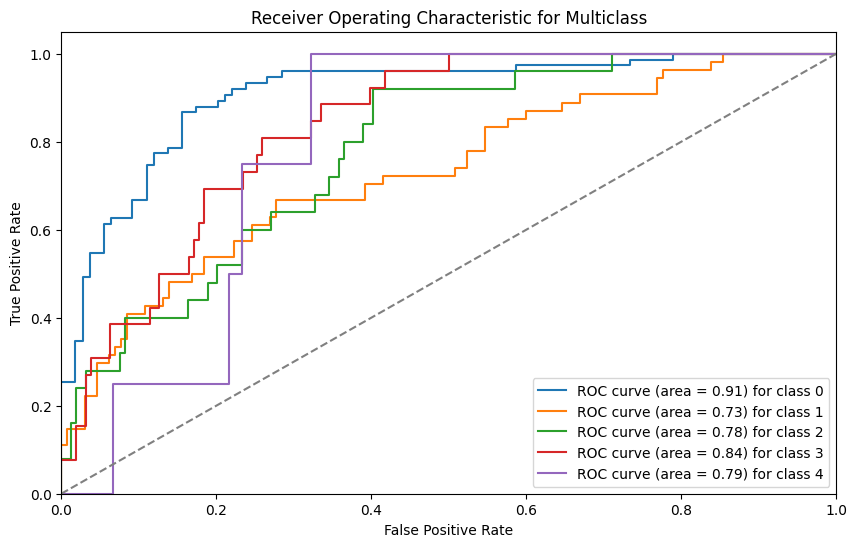

In [115]:
# Assuming your y_test contains multiclass labels
# Binarize the output
classes = [0, 1, 2, 3, 4]  # Update this list according to your dataset's classes
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Get prediction probabilities for all classes
y_pred_proba_gb = gb_model.predict_proba(X_test_processed)

# Initialize the plot
plt.figure(figsize=(10, 6))

# Compute and plot ROC curve and ROC AUC for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba_gb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f}) for class {classes[i]}')

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Customizing the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multiclass')
plt.legend(loc='lower right')
plt.show()


3: XGBoost

  **.Classifier**

In [119]:
# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=200,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit the model
xgb_model.fit(X_train_processed, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.75      0.91      0.82        75
         1.0       0.55      0.57      0.56        54
         2.0       0.47      0.28      0.35        25
         3.0       0.47      0.35      0.40        26
         4.0       0.00      0.00      0.00         4

    accuracy                           0.62       184
   macro avg       0.45      0.42      0.43       184
weighted avg       0.60      0.62      0.60       184



   **.Evaluation**

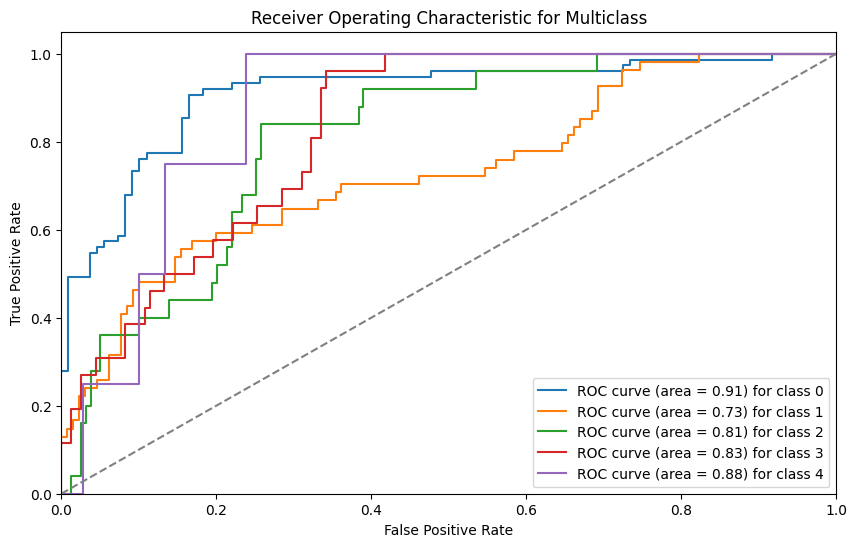

In [121]:
classes = [0, 1, 2, 3, 4]
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

# Get prediction probabilities for all classes using XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)

# Initialize the plot
plt.figure(figsize=(10, 6))

# Compute and plot ROC curve and ROC AUC for each class
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f}) for class {classes[i]}')

# Plot diagonal line for random guessing
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Customizing the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multiclass')
plt.legend(loc='lower right')
plt.show()
